In [1]:
### Code to read in h5 files as detailed in the first guidebook
# Import necessary packages
import sys

sys.path.append(r"C:\Users\lwlav\.vscode\repo\BOEM-Oak-Island\Post_Processing_Scripts")
import pandas as pd
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import signal
import glob
import utide
plt.rcParams.update({'font.size': 14}) 

deployment_num = [1,2,3,4,5]
sensor_spot = ["E","C","S"]
# directory_initial_user_path = r"/Volumes/BOEM/"  # Katherine
# directory_initial_user_path = r"/Volumes/kanarde/BOEM/"  # Brooke
directory_initial_user_path = r"Z:/"  # Levi

def tidal_ellipse(u,v,t,constituents = ['M2'], sensor = "S0",dep = "1",plotter = True):
 
    coef = utide.solve(t, u, v, lat=33.9, method="ols", conf_int="linear", constit=constituents)

    #With coefficients, we can reconstruct the tidal signal and plot the ellipses
    out = utide.reconstruct(t, coef)

    # Extract the fitted velocities
    u_fit = out.u
    v_fit = out.v
    if plotter == True:
        # Plotting the ellipse
        plt.figure(figsize=(6, 6))
        plt.plot(u_fit,v_fit, label='Reconstructed Tidal Ellipse')
        plt.axhline(0, color='black', lw=1, ls='--')
        plt.axvline(0, color='black', lw=1, ls='--')
        plt.xlabel("East Velocity (m/s)")
        plt.ylabel("North Velocity (m/s)")
        plt.title(f"Tidal Ellipse for {constituents[0]} - sensor {sensor} - Deployment {dep}")
        plt.axis('equal') # Crucial for seeing the true shape of the ellipse
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    #Remove tidal ellipse from original signal to get residuals
    u_residual = u - u_fit
    v_residual = v - v_fit

    return coef, out, pd.DataFrame({
        "U_residual": u_residual,
        "V_residual": v_residual
    })


In [2]:
# Import bulkstats and create dictionary for each sensor
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")  # Extract S0 or S1
            sensor_serial = sensor_location[1]
            if sensor_serial == "103071" or dep ==5:
                files = ["SSC","Time","StokesTransport","DepthAveragedEastVelocity","DepthAveragedNorthVelocity","StokesDriftDirection","StokesDriftMagnitude"]
            else:
                files = ["SSC","Time","StokesTransport","DepthAveragedEastVelocity","DepthAveragedNorthVelocity","StokesDriftDirection","StokesDriftMagnitude"]
            waves = {}
            for file in files:
                file_path = os.path.join(sensor_id, file)  # file path
                df = pd.read_hdf(file_path)  # read the file into a Pandas dataframe
                file_name = file.split(".")[0]  # file name
                print(file_name)
                waves[file_name] = df  # store dataframe
            globals()[f"waves_{sensor_location[0]}_{dep}"] = waves
            

SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
StokesDriftMagnitude
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
StokesDriftMagnitude
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
StokesDriftMagnitude
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
StokesDriftMagnitude
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
StokesDriftMagnitude
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
StokesDriftMagnitude
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
StokesDriftMagnitude
SSC
Time
StokesTransport
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
StokesDriftDirection
StokesDriftMagnitude
SSC
Time
StokesTransport
DepthAveragedEa

In [16]:
animation_data = {}
sensor_coords = {
"S0": (-77.942100, 33.730200),
"S1": (-77.983700, 33.793700),
"C0": (-77.884083, 33.664683),
"E0": (-77.900567, 33.738750),
"E1": (-77.924600, 33.805600) # 33.805593 -77.924593$
}

import matplotlib.animation as animation
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:# Extract S0, S1, E1
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            print(f"Processing {sensor_location}...")
            waves = globals()[f"waves_{sensor_location}_{dep}"]
            u = waves['DepthAveragedEastVelocity'].values.squeeze()
            v = waves['DepthAveragedNorthVelocity'].values.squeeze()
            t = waves['Time'].values.squeeze()
            transport = np.nanmean(waves['StokesTransport'],axis = 1)
            coef, out, resid = tidal_ellipse(u,v,t, plotter = 'False')
            print(coef['theta'])

            eulerian_u = waves['SSC'].values.squeeze() * out.u
            eulerian_v = waves['SSC'].values.squeeze() * out.v

            stokes_u = transport * np.cos(np.deg2rad(180 +np.nanmean(waves['StokesDriftDirection'],axis = 1)))
            stokes_v = transport * np.sin(np.deg2rad(180 +np.nanmean(waves['StokesDriftDirection'], axis = 1)))

            waves['sum_ustokes'] = np.nansum(stokes_u)
            waves['sum_vstokes'] = np.nansum(stokes_v)
            waves['sum_ueuler'] = np.nansum(eulerian_u)
            waves['sum_veuler'] = np.nansum(eulerian_v)
            waves['total_u'] = np.nansum(u * waves['SSC'].values.squeeze())
            waves['total_v'] = np.nansum(v * waves['SSC'].values.squeeze())

            waves['sum_total'] = np.sqrt(waves['total_u']**2 + waves['total_v']**2)
            waves['sum_euler'] = np.sqrt(waves['sum_ueuler']**2 + waves['sum_veuler']**2)
            waves['sum_stokes'] = np.sqrt(waves['sum_ustokes']**2 + waves['sum_vstokes']**2)
            waves['sum_stokeseuler'] = np.sqrt(waves['sum_ustokes']**2 + waves['sum_vstokes']**2 + waves['sum_ueuler']**2 + waves['sum_veuler']**2)

            waves['stokes/euler'] = np.sqrt(waves['sum_ustokes']**2 + waves['sum_vstokes']**2)/np.sqrt(waves['sum_ueuler']**2 + waves['sum_veuler']**2)
            

Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
[4.06593061]
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
[144.18839234]
Processing S1...
solve: matrix prep ... solution ... 

C:\Users\lwlav\AppData\Local\Temp\ipykernel_81208\3268551183.py:23: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)
C:\Users\lwlav\AppData\Local\Temp\ipykernel_81208\3268551183.py:23: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)
C:\Users\lwlav\AppData\Local\Temp\ipykernel_81208\3268551183.py:23: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)


done.
prep/calcs ... done.
[108.35815785]
Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
[175.30657014]
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
[166.48619456]
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
[119.69931024]
Processing E0...
solve: matrix prep ... solution ... 

C:\Users\lwlav\AppData\Local\Temp\ipykernel_81208\3268551183.py:23: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)
C:\Users\lwlav\AppData\Local\Temp\ipykernel_81208\3268551183.py:23: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)
C:\Users\lwlav\AppData\Local\Temp\ipykernel_81208\3268551183.py:23: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)


done.
prep/calcs ... done.
[176.52746499]
Processing C0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
[39.77722]
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
[154.96926169]
Processing E1...
solve: matrix prep ... solution ... 

C:\Users\lwlav\AppData\Local\Temp\ipykernel_81208\3268551183.py:23: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)
C:\Users\lwlav\AppData\Local\Temp\ipykernel_81208\3268551183.py:23: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)


done.
prep/calcs ... done.
[49.07661469]
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
[122.46761178]
Processing C0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
[5.15608662]
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
[117.30754033]


C:\Users\lwlav\AppData\Local\Temp\ipykernel_81208\3268551183.py:23: RuntimeWarning: Mean of empty slice
  transport = np.nanmean(waves['StokesTransport'],axis = 1)


In [4]:
# #Calculate eulerian transport
# u = waves_E1_1['DepthAveragedEastVelocity'].values.squeeze()
# v = waves_E1_1['DepthAveragedNorthVelocity'].values.squeeze()
# t = waves_E1_1['Time'].values.squeeze()
# transport = np.nanmean(waves_E1_1['StokesTransport'],axis = 1)
# coef, out, resid = tidal_ellipse(u,v,t, plotter = 'False')

# eulerian_u = waves_E1_1['SSC'].values.squeeze() * out.u
# eulerian_v = waves_E1_1['SSC'].values.squeeze() * out.v

# stokes_u = transport * np.cos(np.deg2rad(np.nanmean(waves_E1_1['StokesDriftDirection'],axis = 1)))
# stokes_v = transport * np.sin(np.deg2rad(np.nanmean(waves_E1_1['StokesDriftDirection'], axis = 1)))

# x = waves_E1_1['Time'].values.squeeze()
# y = np.zeros(len(x))
# euler_mag = np.sqrt(eulerian_u**2 + eulerian_v**2)

# norm = mcolors.Normalize (vmin = 0,vmax = 35)
# plt.figure(figsize=(14,6))
# q = plt.quiver(x,y,eulerian_u,eulerian_v,euler_mag,cmap = 'PuBu', label = 'Eulerian Transport',scale = 300, norm=norm)
# cmap = plt.colorbar(q, label = r'Mass Transport ($dB\frac{m}{s}$)')
# plt.title('Eulerian Transport Over Time for Deployment 1 E1')
# plt.xlabel('Time (YYYY-MM-DD)')
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14,6))
# q = plt.quiver(x,y,stokes_u,stokes_v,transport,cmap = 'PuBu', label = r'Stokes Transport',scale = 300,norm=norm)
# cmap = plt.colorbar(q, label = r'Mass Transport ($dB\frac{m}{s}$)')
# plt.title('Stokes Drift Over Time for Deployment 1 E1')
# plt.xlabel('Time (YYYY-MM-DD)')
# plt.tight_layout()
# plt.show()


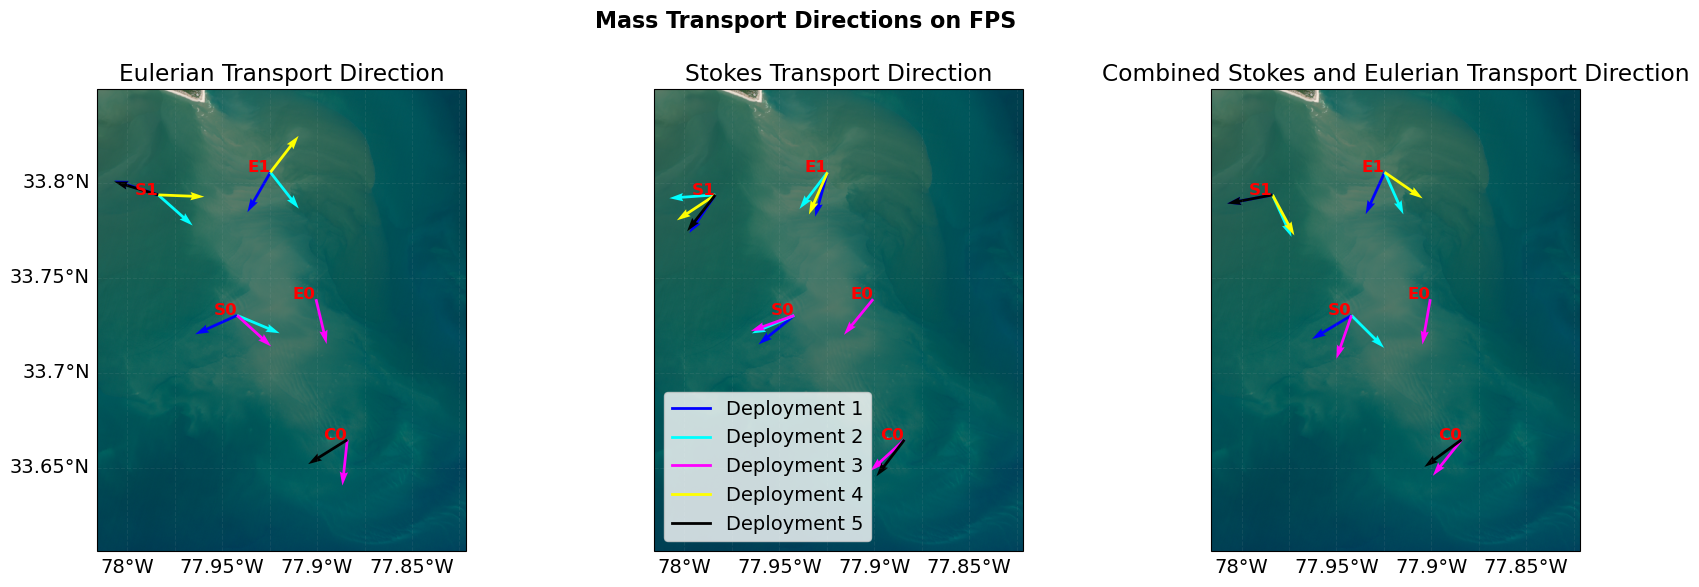

In [5]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import rasterio
import cartopy.crs as ccrs

# Helper function to normalize vectors to uniform length
def normalize_vector(u, v):
    mag = np.hypot(u, v)
    # Prevent division by zero if magnitude is 0
    u_norm = np.where(mag > 0, u / mag, 0)
    v_norm = np.where(mag > 0, v / mag, 0)
    return u_norm, v_norm

filepath = r"z:\deployment_3\2025-02-28-16bitTiff.tiff"
src = rasterio.open(filepath)
img16 = src.read()

# Basic normalization for 8-bit display
img8 = ((img16 - np.min(img16)) / (np.max(img16) - np.min(img16)) * 255).astype(np.uint8)

# Changed figsize to be wider (18x6) instead of taller (12x20) for a 1x3 grid
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={"projection": ccrs.PlateCarree()})
extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# Plot background images
for ax in [ax1, ax2, ax3]:
    ax.imshow(
        img8.transpose(1, 2, 0),
        origin="upper",
        extent=extent, 
        transform=ccrs.PlateCarree()
    )

lander_coords = {
    "S0": (-77.942100, 33.730200),
    "S1": (-77.983700, 33.793700),
    "C0": (-77.884083, 33.664683),
    "E0": (-77.900567, 33.738750),
    "E1": (-77.924600, 33.805600)
}

deployment_colors = {
    1: 'blue',
    2: 'cyan',
    3: 'magenta',
    4: 'yellow',
    5: 'black',
}

# Quiver scaling factor for normalized (unit length) vectors
ARROW_SCALE = 8 

for dep in deployment_num:
    dep_color = deployment_colors.get(dep, 'white')
    for spots in sensor_spot:
        # Fixed pathing (removed leading slash to avoid resetting root path)
        initpath = os.path.join(directory_initial_user_path, f"deployment_{dep}", "BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id).split("_")[0]  # Extract S0 or S1
            data = globals()[f"waves_{sensor_location}_{dep}"]
            
            # Fetch coordinates once per sensor
            lon, lat = lander_coords.get(sensor_location, lander_coords["S0"])

            # Eulerian
            u1, v1 = data['sum_ueuler'], data['sum_veuler']
            u1_n, v1_n = normalize_vector(u1, v1)
            ax1.quiver(lon, lat, u1_n, v1_n, color=dep_color, scale=ARROW_SCALE)

            # Stokes
            u2, v2 = data['sum_ustokes'], data['sum_vstokes']
            u2_n, v2_n = normalize_vector(u2, v2)
            ax2.quiver(lon, lat, u2_n, v2_n, color=dep_color, scale=ARROW_SCALE)

            # Total (Eulerian + Stokes)
            u3, v3 = data['sum_ustokes'] + data['sum_ueuler'], data['sum_vstokes'] + data['sum_veuler']
            u3_n, v3_n = normalize_vector(u3, v3)
            ax3.quiver(lon, lat, u3_n, v3_n, color=dep_color, scale=ARROW_SCALE)

            # Add a label for the lander (Only on ax1, only first deployment to minimize clutter)
            if dep == 1:  
                ax1.text(lon, lat, sensor_location, transform=ccrs.PlateCarree(), 
                         fontsize=12, fontweight='bold', ha='right', color='red')
                ax2.text(lon, lat, sensor_location, transform=ccrs.PlateCarree(), 
                         fontsize=12, fontweight='bold', ha='right', color='red')
                ax3.text(lon, lat, sensor_location, transform=ccrs.PlateCarree(), 
                         fontsize=12, fontweight='bold', ha='right', color='red')

# Gridlines & Static Text Labels 
for i, ax in enumerate([ax1, ax2, ax3]):
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.1)
    gl.top_labels = False
    gl.right_labels = False
    if i > 0: 
        gl.left_labels = False # Only show Y-axis labels on the leftmost plot
        
    # Add static labels for E0 and C0 across all plots
    for static_label in ["E0", "C0"]:
        lon_s, lat_s = lander_coords[static_label]
        ax.text(lon_s, lat_s, static_label, transform=ccrs.PlateCarree(), 
                fontsize=12, fontweight='bold', ha='right', color='red')

#Single Legend Construction 
legend_elements = [
    mlines.Line2D([], [], color=color, linewidth=2, label=f'Deployment {dep_num}')
    for dep_num, color in deployment_colors.items()
]
# Places one clean legend on the last subplot
ax2.legend(handles=legend_elements, loc='lower left', 
           title_fontproperties={'weight': 'bold'})

# Corrected Global Centered Title
fig.suptitle("Mass Transport Directions on FPS", fontsize=16, fontweight='bold', y=0.98)
ax1.set_title('Eulerian Transport Direction')
ax2.set_title('Stokes Transport Direction')
ax3.set_title('Combined Stokes and Eulerian Transport Direction')

plt.tight_layout()
plt.show()

Processing E1...
Processing S0...
Processing S1...
Processing E1...
Processing S0...
Processing S1...
Processing E0...
Processing C0...
Processing S0...
Processing E1...
Processing S1...
Processing C0...
Processing S1...


Text(0.5, 1.0, 'Total Mass Transport')

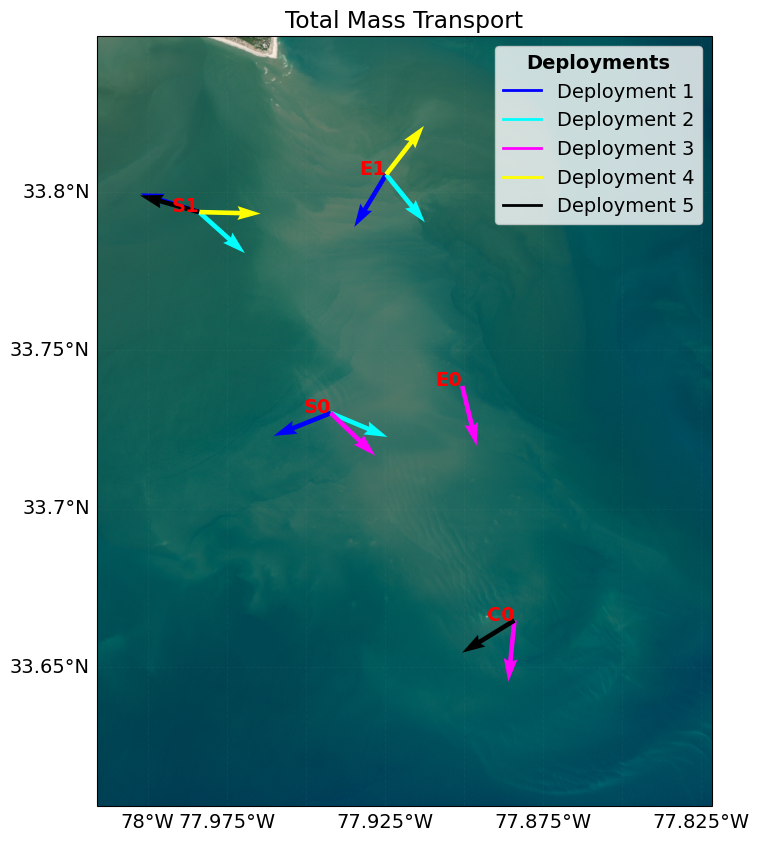

In [20]:
import rasterio
import cartopy.crs as ccrs
import matplotlib.lines as mlines#Plotter that overlays tidal ellipses from all deployments and landers on top of shoals 
# Convert dep to string to match filename parsing

filepath  = r"z:\deployment_3\2025-02-28-16bitTiff.tiff"

src = rasterio.open(filepath)
img16 = src.read()
# Basic normalization for 8-bit display
img8 = ((img16 - np.min(img16)) / (np.max(img16) - np.min(img16)) * 255).astype(np.uint8)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})

extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
ax.imshow(
    img8.transpose(1, 2, 0),
    origin="upper",
    extent=extent, 
    transform=ccrs.PlateCarree()
)

lander_coords = {
"S0": (-77.942100, 33.730200),
"S1": (-77.983700, 33.793700),
"C0": (-77.884083, 33.664683),
"E0": (-77.900567, 33.738750),
"E1": (-77.924600, 33.805600) # 33.805593 -77.924593$
}

deployment_colors = {
    1: 'blue',
    2: 'cyan',
    3: 'magenta',
    4: 'yellow',
    5: 'black',
}

ARROW_SCALE = 10

for dep in deployment_num:
    dep_color = deployment_colors.get(dep, 'white')
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            data = globals()[f"waves_{sensor_location}_{dep}"]
            print(f"Processing {sensor_location}...")

            # Get coords from dictionary, default to S0 if not found
            sensor = str(sensor_location)
            lon, lat = lander_coords.get(sensor, lander_coords["S0"])
            u = np.nansum(data['DepthAveragedEastVelocity'] * data['SSC'])
            v = np.nansum(data['DepthAveragedNorthVelocity'] * data['SSC'])

            # u = u - data['sum_ustokes'] - data['sum_ueuler']
            # v = v - data['sum_vstokes'] - data['sum_veuler']
            
            u_n, v_n = normalize_vector(u, v)

            # Plot the ellipse
            ax.quiver(lon, lat,u_n,v_n,color=dep_color, label=f"{sensor_location} - Deployment {dep}",scale = ARROW_SCALE)

            # Add a label for the lander
            if dep == 1:  # Only label for the first deployment to avoid clutter
                ax.text(lon, lat, sensor_location, transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')

# Gridlines and Labels
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.05)
gl.top_labels = False
gl.right_labels = False

#Add labels for E0 and C0
lon, lat = lander_coords.get("E0", (lander_coords["S0"]))
ax.text(lon, lat, "E0", transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')
lon, lat = lander_coords.get("C0", (lander_coords["S0"]))
ax.text(lon, lat, "C0", transform=ccrs.PlateCarree(), 
                    fontsize=14, fontweight='bold', ha='right',color='red')

legend_elements = []

# Loop through your color dictionary and create a legend entry for each one
for dep_num, color in deployment_colors.items():
    line = mlines.Line2D([], [], color=color, linewidth=2, label=f'Deployment {dep_num}')
    legend_elements.append(line)

# Add the legend to the map with a nice title
ax.legend(handles=legend_elements, loc='upper right', title="Deployments", 
          title_fontproperties={'weight': 'bold'})

plt.title(f"Total Mass Transport")

In [21]:
print(u,v)
print(u1,v1)

-1799.272321470779 508.24498271093296
-1655.9417770173266 503.3963990837387


In [7]:
#Table comparing Eulerian vs Stokes Drift Magnitudes
import tabulate
transport_comps = [
    ["Ratio of Stokes Transport To Eulerian Transport", "Summer-->Fall", "Fall-->Winter", "Winter-->Spring", "Spring-->Summer", "Summer-->Fall"],
    ["S0", waves_S0_1['stokes/euler'], waves_S0_2['stokes/euler'], waves_S0_3['stokes/euler'], None, None],
    ["S1", waves_S1_1['stokes/euler'], waves_S1_2['stokes/euler'], None, waves_S1_4['stokes/euler'], waves_S1_5['stokes/euler']],
    ["E0",  None, None, waves_E0_3['stokes/euler'],  None,  None],
    ["E1", waves_E1_1['stokes/euler'], waves_E1_2['stokes/euler'],  None, waves_E1_4['stokes/euler'],  None],
    ["C0",  None,  None, waves_C0_3['stokes/euler'],  None, waves_C0_5['stokes/euler']]
]
print(tabulate.tabulate(transport_comps, headers="firstrow", tablefmt="double_grid", missingval="N/A"))

╔═══════════════════════════════════════════════════╦═════════════════╦═════════════════╦═══════════════════╦═══════════════════╦═════════════════╗
║ Ratio of Stokes Transport To Eulerian Transport   ║   Summer-->Fall ║   Fall-->Winter ║   Winter-->Spring ║   Spring-->Summer ║   Summer-->Fall ║
╠═══════════════════════════════════════════════════╬═════════════════╬═════════════════╬═══════════════════╬═══════════════════╬═════════════════╣
║ S0                                                ║        0.846526 ║        0.406418 ║          1.18075  ║        N/A        ║      N/A        ║
╠═══════════════════════════════════════════════════╬═════════════════╬═════════════════╬═══════════════════╬═══════════════════╬═════════════════╣
║ S1                                                ║        0.683617 ║        0.433295 ║        N/A        ║          0.864331 ║        0.702538 ║
╠═══════════════════════════════════════════════════╬═════════════════╬═════════════════╬═══════════════════╬═══

In [8]:
#Look at wind data
for dep in deployment_num:
    windpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats/Wind.xlsx")
    wind = pd.read_excel(windpath, header=0, skiprows = range(0, 12))
    wind = wind.rename(columns={
    'Date/Time (Eastern)': 'date_time',
    'Top-of-the-Hour Wind Speed (ms)': 'wind_speed_ms',
    'Top-of-the-Hour Wind Direction (degree)': 'wind_dir_deg'
    })
    globals()[f"wind_{dep}"] = wind
print(wind.keys())

Index(['date_time', 'wind_speed_ms', 'wind_dir_deg'], dtype='str')


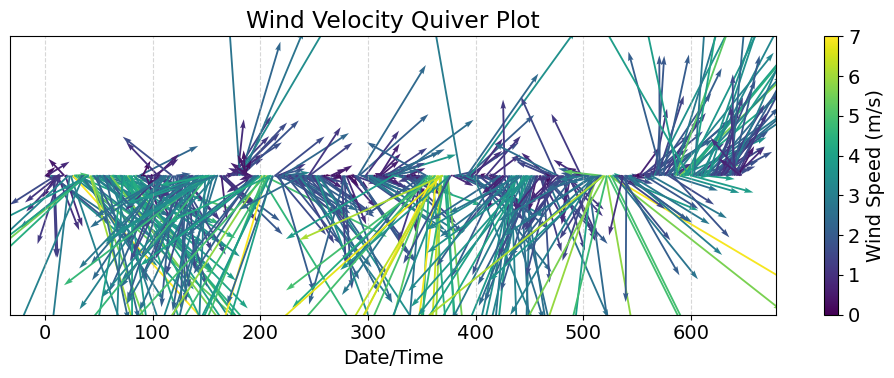

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = wind_2

# 2. Convert meteorological wind direction to mathematical angles in radians
# Note: In meteorology, 0° is North (blowing FROM the north) and moves clockwise.
# In math, 0° is East and moves counter-clockwise.
math_dir_rad = np.radians( df['wind_dir_deg'])

# 3. Calculate U (horizontal/East-West) and V (vertical/North-South) components
df['U'] = df['wind_speed_ms'] * np.cos(math_dir_rad)
df['V'] = df['wind_speed_ms'] * np.sin(math_dir_rad)

# 4. Create the Quiver Plot
plt.figure(figsize=(10, 4))

# We use the index or date for the X-axis, and a baseline of zeros for the Y-axis
x = np.arange(len(df))
y = np.zeros(len(df))

# plt.quiver(X, Y, U, V, ...)   
quiver = plt.quiver(x, y, df['U'], df['V'], df['wind_speed_ms'], 
                    cmap='viridis', angles='uv', scale_units='xy',scale=40)

# Formatting the plot
plt.colorbar(quiver, label='Wind Speed (m/s)')
# plt.xticks(x, df['date_time'], rotation=15)
plt.yticks([])  # Hide Y-axis since it's just a 1D timeline baseline
plt.xlabel('Date/Time')
plt.title('Wind Velocity Quiver Plot')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

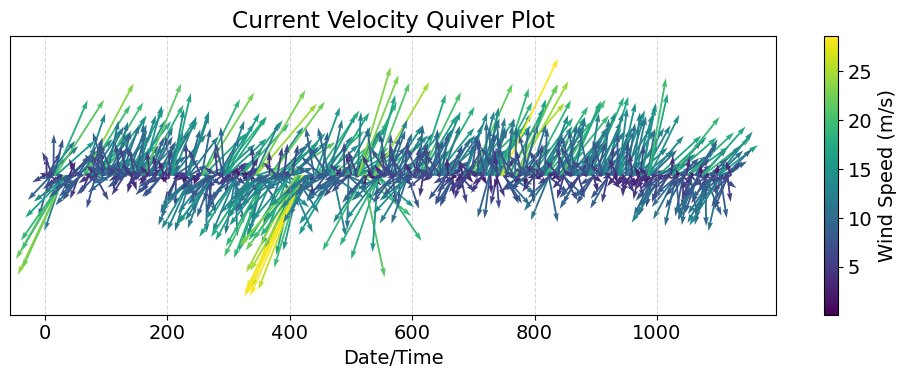

In [11]:
ut = waves_E1_4['DepthAveragedEastVelocity'] * waves_E1_4['SSC']
vt = waves_E1_4['DepthAveragedNorthVelocity'] * waves_E1_4['SSC']

scale = np.sqrt(ut**2 + vt**2)

truetotal = np.nansum(scale)

plt.figure(figsize=(10, 4))

# We use the index or date for the X-axis, and a baseline of zeros for the Y-axis
x = np.arange(len(ut))
y = np.zeros(len(ut))

# plt.quiver(X, Y, U, V, ...)   
quiver = plt.quiver(x, y, ut, vt, scale, 
                    cmap='viridis', angles='uv', scale_units='xy',scale=500)

# Formatting the plot
plt.colorbar(quiver, label='Wind Speed (m/s)')
# plt.xticks(x, df['date_time'], rotation=15)
plt.yticks([])  # Hide Y-axis since it's just a 1D timeline baseline
plt.xlabel('Date/Time')
plt.title('Current Velocity Quiver Plot')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

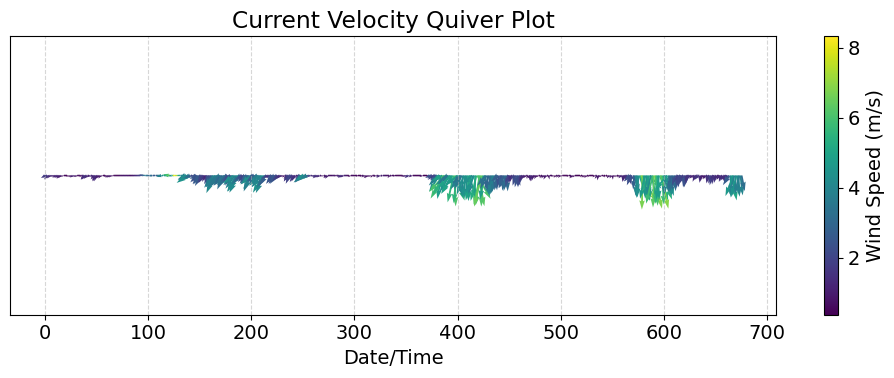

In [13]:
u = stokes_u
v = stokes_v
scale = np.sqrt(u**2 + v**2)

plt.figure(figsize=(10, 4))

# We use the index or date for the X-axis, and a baseline of zeros for the Y-axis
x = np.arange(len(u))
y = np.zeros(len(u))

# plt.quiver(X, Y, U, V, ...)   
quiver = plt.quiver(x, y, u, v, scale, 
                    cmap='viridis', angles='uv', scale_units='xy',scale=500)

# Formatting the plot
plt.colorbar(quiver, label='Wind Speed (m/s)')
# plt.xticks(x, df['date_time'], rotation=15)
plt.yticks([])  # Hide Y-axis since it's just a 1D timeline baseline
plt.xlabel('Date/Time')
plt.title('Current Velocity Quiver Plot')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

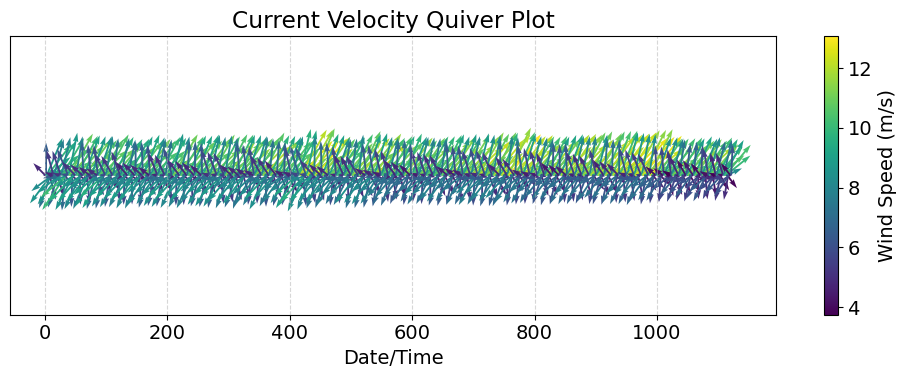

In [ ]:
u = eulerian_u
v = eulerian_v
scale = np.sqrt(u**2 + v**2)

plt.figure(figsize=(10, 4))

# We use the index or date for the X-axis, and a baseline of zeros for the Y-axis
x = np.arange(len(u))
y = np.zeros(len(u))

# plt.quiver(X, Y, U, V, ...)   
quiver = plt.quiver(x, y, u, v, scale, 
                    cmap='viridis', angles='uv', scale_units='xy',scale=500)

# Formatting the plot
plt.colorbar(quiver, label='Wind Speed (m/s)')
# plt.xticks(x, df['date_time'], rotation=15)
plt.yticks([])  # Hide Y-axis since it's just a 1D timeline baseline
plt.xlabel('Date/Time')
plt.title('Current Velocity Quiver Plot')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

0.6809229883243781


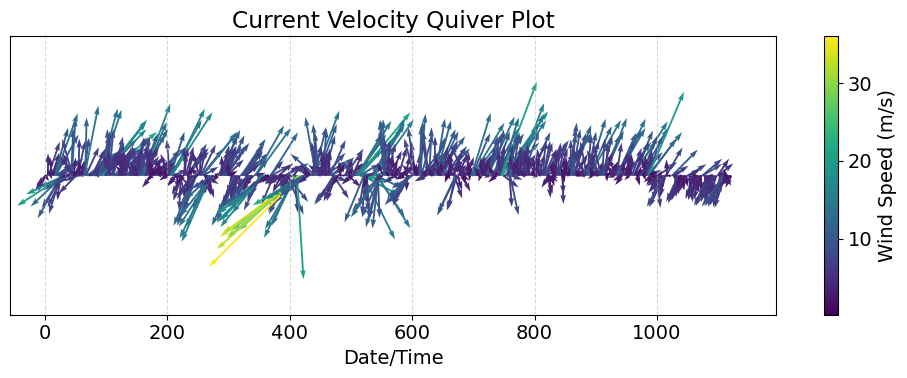

In [ ]:
resid_u = ut.values.squeeze().T - stokes_u - eulerian_u
resid_v = vt.values.squeeze().T - stokes_v - eulerian_v

scale = np.sqrt(resid_u**2 + resid_v**2)

total = np.nansum(scale)

stokes + euler
print(total/truetotal)

plt.figure(figsize=(10, 4))

# We use the index or date for the X-axis, and a baseline of zeros for the Y-axis
x = np.arange(len(u))
y = np.zeros(len(u))

# plt.quiver(X, Y, U, V, ...)   
quiver = plt.quiver(x, y, u, v, scale, 
                    cmap='viridis', angles='uv', scale_units='xy',scale=500)

# Formatting the plot
plt.colorbar(quiver, label='Wind Speed (m/s)')
# plt.xticks(x, df['date_time'], rotation=15)
plt.yticks([])  # Hide Y-axis since it's just a 1D timeline baseline
plt.xlabel('Date/Time')
plt.title('Current Velocity Quiver Plot')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
print(waves_E1_1['sum_stokeseuler']/waves_E1_1['sum_total'])
print(waves['stokes/euler'])

1.1289241374072307


In [ ]:
eccentricity = [["Eccentricity", "Summer-->Fall", "Fall-->Winter","Winter-->Spring", "Spring-->Summer", "Summer-->Fall"],
            ["S0", waves_S0_1['Eccentricity'][0] , waves_S0_2['Eccentricity'][0], waves_S0_3['Eccentricity'][0], None, None],
            ["S1", waves_S1_1['Eccentricity'][0],waves_S1_2['Eccentricity'][0], None, waves_S1_4['Eccentricity'][0],  waves_S1_5['Eccentricity'][0]],
            ["E0", None, None, waves_E0_3['Eccentricity'][0],None, None],
            ["E1", waves_E1_1['Eccentricity'][0], waves_E1_2['Eccentricity'][0],None,waves_E1_4['Eccentricity'][0], None],
            ["C0", None, None, waves_C0_3['Eccentricity'][0],None,waves_C0_5['Eccentricity'][0]],]

print(tabulate.tabulate(eccentricity, headers="firstrow", tablefmt="double_grid",missingval="N/A",floatfmt=".2f"))